In [1]:
%matplotlib widget
import warnings
from tqdm import TqdmExperimentalWarning
warnings.filterwarnings("ignore", category=TqdmExperimentalWarning)

import matplotlib.pyplot as plt
import os
import torch
os.environ['TORCH_CUDA_ARCH_LIST'] = f'{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}'
import warp as wp; wp.init()

import torch
# from compressibleSPH.gencase import *
from compressibleSPH.sample import generateInitialVariables, SamplingScheme
from compressibleSPH.sampling import  sampleParticles
# from waves.util import plotState, plotInitialState
# from simulation import runSimulation
from compressibleSPH.utils import getCurrentTimestamp
from argparse import ArgumentParser
from compressibleSPH.casefile import argparse_defaults_from_casefile, load_casefile

# from compressibleSPH.systemv3 import WaveSystemStatev3
from compressibleSPH.sample import smoothState
# from compressibleSPH.systemv3 import WaveSystemv3, f_wave_equation
from integrators.integration import *
from compressibleSPH.utils import *
from sphWarpCore import *
# from compressibleSPH.systemv3 import WaveSystemStatev3

from sphWarpCore.radiusSearch.verlet import *
from sphWarpCore.radius import AdjacencyList
from sphWarpCore.operations import *
from sphWarpCore.enumTypes import *

from sphWarpCore import *
# from waves.sampling import sampleParticles
# from compressibleSPH.systemv3 import sampleInitialWaveState
# from compressibleSPH.systemv3 import computeDt
from compressibleSPH.sampling import finalizeWaveSystemSetup
from compressibleSPH.shape_generation import populateSourceObstacleGridsStructured

from compressibleSPH.config import SimulationConfig, CompressibleSPHConfig
from compressibleSPH.caseUtils.sod import *
from compressibleSPH.util import *
from compressibleSPH.schemes import *
from sphWarpCore.diffusion.viscosity import DiffusionParameters

from diffSPH.enums import ViscositySwitch, KernelType
from torch.profiler import profile, record_function, ProfilerActivity
from tqdm.autonotebook import tqdm

Warp 1.12.0 initialized:
   CUDA Toolkit 12.9, Driver 13.2
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "NVIDIA RTX PRO 500 Blackwell Generation Laptop GPU" (6 GiB, sm_120, mempool enabled)
   Kernel cache:
     /home/lu26029/.cache/warp/1.12.0


In [2]:
nx = 800
gamma = 5/3
leftState = sodInitialState(1, 1, 0)
rightState = sodInitialState(0.1795, 0.25, 0)
samplingRatio = 1
smoothIC = True
timeLimit = 0.15

L = 2
dim = 1
n_h = 4
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
dtype = torch.float32

config = SimulationConfig(
    domain = buildDomainDescription(L, dim, True, device, dtype),
    dim = dim,
    kernel = KernelFunctions.Wendland2,
    targetNeighbors = n_h_to_nH(n_h, dim),
    supportMode = SupportScheme.Gather,
    gradientMode = GradientScheme.Difference,
    laplacianMode = LaplacianScheme.Brookshaw,
    integrationScheme = IntegrationSchemeType.rungeKutta2,
    samplingScheme = SamplingScheme.regular,
    device = device,
    dtype = dtype,
    dt = 1e-3,
    adaptiveDt = False,
    cflFactor=0.3,
)

diffusionParams = DiffusionParameters()
diffusionParams.c_s = 1
diffusionParams.C_l = 1
diffusionParams.C_q = 2
diffusionParams.Cu_l = 1
diffusionParams.Cu_q = 2
diffusionParams.K = 1.0
diffusionParams.thermalConductivity = 0.5
diffusionParams.viscosityTerm = 3
diffusionParams.thermalConducitiyTerm = 9
diffusionParams.scaleBeta = False
diffusionParams.monaghanSwitch = True
diffusionParams.correctXi = True

compressibleSPHConfig = CompressibleSPHConfig(
    gamma = gamma,
    rho0 = leftState.rho,
    diffusionParams = diffusionParams,
)
integrator = getIntegrator(config.integrationScheme)


In [3]:

from warp import Kernel

from compressibleSPH.config import SimulationConfig
from compressibleSPH.utils import *
from sphWarpCore import *
import torch
from compressibleSPH.system import *
from compressibleSPH.modules import idealGasEOS, evaluateOptimalSupport
# from optimalSupport import evaluateOptimalSupport

# from sphWarpCore.kernels.wp_kernel import sphKernel
from diffSPH.kernels import Kernel as diffSPHKernel
from diffSPH.kernels import KernelType

# class KernelFunctions(Enum):
#     Poly6 = 20
#     CubicSpline = 30
#     QuarticSpline = 31
#     QuinticSpline = 32
#     B7 = 33
#     Wendland2 = 0
#     Wendland4 = 1
#     Wendland6 = 2
#     Spiky = 21
#     ViscosityKernel = 30
#     CohesionKernel = 31
#     AdhesionKernel = 32

# class KernelType(Enum):
#     Poly6 = 0
#     CubicSpline = 1
#     QuarticSpline = 2
#     QuinticSpline = 3
#     B7 = 4
#     Wendland2 = 5
#     Wendland4 = 6
#     Wendland6 = 7
#     Spiky = 8
#     ViscosityKernel = 9
#     CohesionKernel = 10
#     AdhesionKernel = 11

def warpKernelToDiffSPHKernel(
        warpKernel: KernelFunctions
):
    if warpKernel == KernelFunctions.Poly6:
        return KernelType.Poly6
    elif warpKernel == KernelFunctions.CubicSpline:
        return KernelType.CubicSpline
    elif warpKernel == KernelFunctions.QuarticSpline:
        return KernelType.QuarticSpline
    elif warpKernel == KernelFunctions.QuinticSpline:
        return KernelType.QuinticSpline
    elif warpKernel == KernelFunctions.B7:
        return KernelType.B7
    elif warpKernel == KernelFunctions.Wendland2:
        return KernelType.Wendland2
    elif warpKernel == KernelFunctions.Wendland4:
        return KernelType.Wendland4
    elif warpKernel == KernelFunctions.Wendland6:
        return KernelType.Wendland6
    elif warpKernel == KernelFunctions.Spiky:
        return KernelType.Spiky
    elif warpKernel == KernelFunctions.ViscosityKernel:
        return KernelType.ViscosityKernel
    elif warpKernel == KernelFunctions.CohesionKernel:
        return KernelType.CohesionKernel
    elif warpKernel == KernelFunctions.AdhesionKernel:
        return KernelType.AdhesionKernel
    else:
        raise ValueError(f'Unknown kernel type {warpKernel}')

def buildSedov(
        nx : int = 200,
        dim: int = 2,
        domainExtent: float = 2,
        periodicDomain: bool = True,

        rho0 : float = 1,
        E0 : float = 1,
        initialization: str = 'hat',
        gamma : float = 5/3,
        kernel: KernelType = KernelType.B7,
        targetNeighbors = 50,

        dtype = torch.float32,
        device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu'), shellSampling = False, SimulationSystem = CompressibleSystem):
    # dim = 2
    domain = buildDomainDescription(domainExtent, dim, periodic = periodicDomain, device = device, dtype = dtype)

    if initialization == 'singular':
        if nx % 2 == 0:
            warnings.warn('nx should be odd for singular initialization, setting to nx + 1')
            nx += 1
    elif initialization == 'quadrant':
        if nx % 2 == 1:
            warnings.warn('nx should be even for quadrant initialization, setting to nx - 1')
            nx -= 1

    if shellSampling:
        particles_ = sampleShell(nx, domain, targetNeighbors)
    else:
        particles_ = sampleRegularParticles(nx, domain, targetNeighbors)
    # domain = buildDomainDescription(domainExtent * 1.5, dim, periodic = periodicDomain, device = device, dtype = dtype)
    particles_ = particles_._replace(masses = particles_.masses * rho0)

    

    particles = CompressibleState(
        positions = particles_.positions,
        supports = particles_.supports,
        masses = particles_.masses,
        densities = particles_.densities,
        velocities = torch.zeros_like(particles_.positions),
        
        kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
        materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
        UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
        UIDcounter = particles_.positions.shape[0],
        
        internalEnergies = None,
        totalEnergies = None,
        entropies = None,
        pressures = None,
        soundspeeds = None,

        divergence=torch.zeros_like(particles_.densities),
        alpha0s= torch.ones_like(particles_.densities),
        alphas= torch.ones_like(particles_.densities),
    )

    
    densities = warpOperation(
        particles, 
        OperationProperties(
            kernel = config.kernel,
            operation = WarpOperation.Density,
            supportMode = SupportScheme.Gather,
            gradientMode = config.gradientMode,
            laplacianMode = config.laplacianMode,
        ),
        domain = config.domain,
    )
    particles.densities = densities

    wrappedKernel = warpKernelToDiffSPHKernel(kernel)
    # neighborhood, neighbors = evaluateNeighborhood(particles, domain, wrappedKernel, verletScale = 1.0, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)
    # numNeighbors = coo_to_csr(filterNeighborhoodByKind(particles, neighbors.neighbors, which = 'noghost')).rowEntries
    # config = {'targetNeighbors': targetNeighbors, 'domain': domain, 'support': {'iterations': 16, 'scheme': 'Monaghan'}, 'neighborhood': {'algorithm': 'compact'}}
    # rho, h, rhos, hs, neighborhood = evaluateOptimalSupport(particles, wrappedKernel, neighborhood, SupportScheme.Gather, config)

    rho_optimal, h_optimal, adjacency, rhos_iter, supports_iter = evaluateOptimalSupport(particles, config, supportScheme = SupportScheme.Gather)
    # particleState.supports = h_optimal

    particles.densities = rho_optimal
    particles.supports = h_optimal

    P_initial = torch.zeros_like(particles.densities)
    u = 1 / (gamma - 1) * (P_initial / rho_optimal)
    # A_, u_, P_, c_s = idealGasEOS(A = None, u = None, P = P_initial, rho = rho_optimal, gamma = gamma)
    A_, u_, P_, c_s = idealGasEOS(A = None, u = u, P = None, rho = rho_optimal, gamma = gamma)

    internalEnergy = u_ 
    kineticEnergy = torch.linalg.norm(torch.zeros_like(particles.positions), dim = -1) **2/ 2
    totalEnergy = (internalEnergy + kineticEnergy) * particles.masses

    simulationState_ = CompressibleState(
        positions = particles.positions,
        supports = particles.supports,
        masses = particles.masses,
        densities = particles.densities,        
        velocities = torch.zeros_like(particles.positions),

        kinds = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
        materials = torch.zeros_like(particles_.positions[:,0], dtype = torch.int32),
        UIDs = torch.arange(particles_.positions.shape[0], device = device, dtype = torch.int32),
        UIDcounter = particles.positions.shape[0],
        
        internalEnergies = u_,
        totalEnergies = totalEnergy,
        entropies = A_,
        pressures = P_,
        soundspeeds = c_s,

        alphas = torch.ones_like(particles.densities),
        alpha0s = torch.ones_like(particles.densities),
        divergence=torch.zeros_like(particles.densities),
    )
        

    if initialization == 'hat':
        # positions_warp = wp.from_torch(simulationState_.positions)


        W = diffSPHKernel(wrappedKernel, torch.tensor([[0,0]], device = device, dtype = dtype) - simulationState_.positions, simulationState_.supports)
        W = W/W.sum()
        simulationState_.internalEnergies = E0 * W / simulationState_.masses
        A_, u_, P_, c_s = idealGasEOS(A = None, u = simulationState_.internalEnergies, P = None, rho = rho_optimal, gamma = gamma)
        simulationState_.pressures = P_
        simulationState_.soundspeeds = c_s
    elif initialization == 'singular':
        dist = torch.linalg.norm(simulationState_.positions, dim = -1)
        sortedDist, idx = torch.sort(dist)
        u_ = torch.zeros_like(simulationState_.masses)
        u_[idx[0]] = E0 / simulationState_.masses[idx[0]]

        # if sampleShell:
        #     u_[0] = E0 / particles.masses[0]
        # else:
        #     u_grid = u_.reshape(nx, nx)
        #     middle = nx // 2
        #     u_grid[middle, middle] = E0 / particles.masses[middle * nx + middle]
        #     u_ = u_grid.reshape(-1)
        A_, u_, P_, c_s = idealGasEOS(A = None, u = u_, P = None, rho = rho_optimal, gamma = gamma)
        simulationState_.internalEnergies = u_
        simulationState_.pressures = P_
        simulationState_.soundspeeds = c_s
    elif initialization == 'quadrant':
        if shellSampling:
            raise ValueError('Shell sampling not supported for quadrant initialization')
        if dim == 2: 
            nptcl = 4
        elif dim == 1:
            nptcl = 2
            
        dist = torch.linalg.norm(simulationState_.positions, dim = -1)
        sortedDist, idx = torch.sort(dist)
        u_ = torch.zeros_like(simulationState_.masses)
        u_[idx[:nptcl]] = E0 / simulationState_.masses[idx[:nptcl]]
        


        # u_grid = u_.reshape(nx, nx)
        # middle = nx // 2
        # for ix in [middle - 1, middle]:
        #     for iy in [middle - 1, middle]:
        #         u_grid[ix, iy] = E0 / 4 / particles.masses[middle * nx + middle]
        # u_ = u_grid.reshape(-1)
        A_, u_, P_, c_s = idealGasEOS(A = None, u = u_, P = None, rho = rho_optimal, gamma = gamma)
        simulationState_.internalEnergies = u_
        simulationState_.pressures = P_
        simulationState_.soundspeeds = c_s
    else:
        raise ValueError(f'Unknown initialization {initialization}')

    adjacency = buildVerletList(simulationState_, 
                                domain = config.domain,
                                verletScale = 2**(1/config.dim), supportMode = config.supportMode)

    compressibleSystem = CompressibleSystem(
        state=simulationState_, 
        adjacency = adjacency, 
        domain = config.domain)
    
    # particleSystem = SimulationSystem(
    #     systemState = simulationState_,
    #     domain = domain,
    #     neighborhoodInfo = neighborhood,
    #     t = 0
    # )

    return compressibleSystem

def radius(beta, E0, t, rho0, nu):
    return beta *( E0 * t**2 / (rho0)) ** (1/(2+nu))
def velocity(beta, E0, t, rho0, nu):
    return 2/(nu+2) * radius(beta, E0, t, rho0, nu) / t

def beta(nu):
    if nu == 1:
        # return 1 / (answer.alpha ** nu1 )
        return 1.11
    elif nu == 2:
        return 1.12
    elif nu == 3:
        return 1.15

In [4]:
goalRadius = 0.8

gamma = 5/3
rho0 = 1
E0 = 1

compSystem = buildSedov(
    nx = nx, dim = dim, domainExtent = L, 
    periodicDomain = True, 
    rho0 = rho0, E0 = E0, 
    initialization = 'singular', 
    gamma = gamma, kernel = config.kernel, 
    targetNeighbors = config.targetNeighbors, 
    dtype = config.dtype, device = config.device)

Dimension 0: l: 2.0, dx: 0.0024968788493424654, nd: 801, dn: 0.0024968788493424654, offset: 0.0012484394246712327
Module sphWarpCore.radiusSearch.wp_compactHash e835d56 load on device 'cuda:0' took 8.61 ms  (cached)
Module sphWarpCore.operations_grid.wp_density_grid e6317f6 load on device 'cuda:0' took 7.45 ms  (cached)
Module sphWarpCore.operations.wp_density 896c489 load on device 'cuda:0' took 6.19 ms  (cached)
Module compressibleSPH.modules.adaptiveSupport.wp_omega e96da33 load on device 'cuda:0' took 7.60 ms  (cached)


In [5]:
torch.sqrt(compSystem.state.internalEnergies.abs() * gamma * (gamma - 1)).max()

tensor(21.0950, device='cuda:0')

In [6]:
from sphWarpCore.kernels.wp_kernel import sphKernel_xi
targetCFL = 0.3
# The initial state contains density and pressure
# we can get the internal energies for each state via the gas EOS
u = compSystem.state.internalEnergies
c_s = compSystem.state.soundspeeds.max()

print(f"Initial internal energy: u (min: {u.min()}, max: {u.max()}, mean: {u.mean()})")
print(f"Initial sound speed: c_s (min: {c_s.min()}, max: {c_s.max()}, mean: {c_s.mean()})")

# u_left = leftState.p / ((gamma - 1) * leftState.rho)
# u_right = rightState.p / ((gamma - 1) * rightState.rho)
# # this then gives us the speed of sound for each state, which we can use to determine the initial timestep based on the CFL condition
# c_s_left =  np.sqrt(u_left * gamma * (gamma - 1))
# c_s_right =  np.sqrt(u_right * gamma * (gamma - 1))

# We cab then get the minimum support radius based on the initial sampling and use this to get the initial timestep
# The sampling is done such that with a sampling ratio of 1 th left and right states each have nx particles
# The sampling ratio then reduces the number of particles by that factor
# accordingly, the higher resolution is always the unmultiplied L/2 /nx
dx = L / (nx * 2)
h = volumeToSupportHelper(dx, config.targetNeighbors, config.dim)
h = compSystem.state.supports.min()
xi = sphKernel_xi(config.kernel.value, config.dim)
# xi = 1

dt_cfl_left = targetCFL * h / (c_s * xi)
# dt_cfl_right = targetCFL * h / (c_s + h * xi)
initial_dt = torch.min(dt_cfl_left)
config.dt = initial_dt

# print(f"Internal energy left: {u_left}, right: {u_right}")
# print(f"Speed of sound left: {c_s_left}, right: {c_s_right}")
print(f"Initial support radius: {h}, xi: {xi}")
# print(f'')
# print(f"Initial dt based on CFL condition left: {dt_cfl_left}, right: {dt_cfl_right}")
print(f"Initial dt based on CFL condition: {initial_dt}")

Initial internal energy: u (min: 0.0, max: 400.5, mean: 0.5)
Initial sound speed: c_s (min: 21.095022201538086, max: 21.095022201538086, mean: 21.095022201538086)
Initial support radius: 0.009977606125175953, xi: 2.409215095
Initial dt based on CFL condition: 5.8896846894640476e-05


In [7]:
from compressibleSPH.caseUtils.sedov.sedovSolution import SedovSolution
from scipy.optimize import minimize

answer = SedovSolution(
    nDim = dim,
    gamma = gamma,
    rho0 = rho0,
    E0 = E0,
    h0 = 2/nx
)
nu1 = 1.0/(answer.nu + 2.0)
nu2 = 2.0*nu1
goalTime = (goalRadius*(answer.alpha*rho0/E0)**nu1)**(1.0/nu2)
vs, r2, v2, rho2, P2 = answer.shockState(goalTime)
rad_t = lambda t: radius(beta(dim), E0, t, rho0, 1)

targetTime = minimize(lambda t: (rad_t(t) - goalRadius) ** 2, 0.2).x[0]

print(f'Target Time [paper]: {targetTime:8.4g}, {rad_t(targetTime):8.4g} / {answer.shockState(targetTime)[1]:8.4g}')
print(f'Target Time  [code]: {goalTime:8.4g}, {rad_t(goalTime):8.4g} / {answer.shockState(goalTime)[1]:8.4g}')

Target Time [paper]:   0.6119,      0.8 /   0.8531
Target Time  [code]:   0.5556,   0.7502 /      0.8


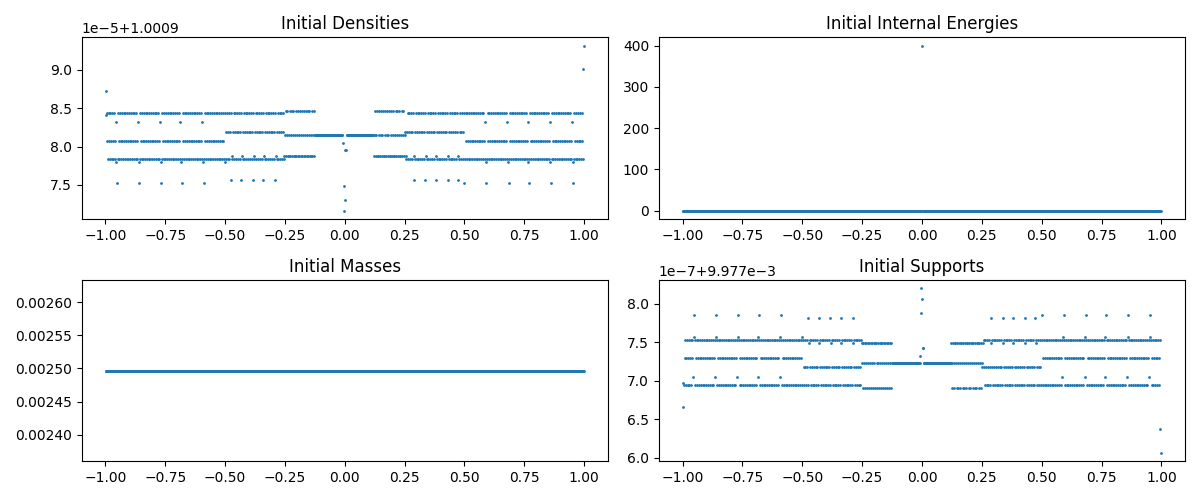

In [8]:
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotToAxis1D(axis[0,0], compSystem.state.positions, compSystem.state.densities, title = 'Initial Densities')
plotToAxis1D(axis[1,0], compSystem.state.positions, compSystem.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,1], compSystem.state.positions, compSystem.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], compSystem.state.positions, compSystem.state.supports, title = 'Initial Supports')
fig.tight_layout()

In [9]:
update, adjacency, state = compressibleSPH_Monaghan(compSystem, config.dt, config, compressibleSPHConfig, verbose = True)

Module sphWarpCore.operations.wp_gradient a37c6d9 load on device 'cuda:0' took 9.03 ms  (cached)
Module sphWarpCore.operations.wp_divergence 2da8877 load on device 'cuda:0' took 8.92 ms  (cached)
Module compressibleSPH.modules.dissipation.wp_diffusion 018284a load on device 'cuda:0' took 13.40 ms  (cached)
Module compressibleSPH.modules.dissipation.wp_conductivity 305a32d load on device 'cuda:0' took 11.64 ms  (cached)
Module compressibleSPH.modules.dissipation.wp_dissipation b589837 load on device 'cuda:0' took 13.68 ms  (cached)


In [10]:
from compressibleSPH.systems.compSPH import CompSPHSystem, CompSPHState
from compressibleSPH.configurations.compSPHConfig import CompSPHConfig
from compressibleSPH.enumTypes import EnergyScheme

compSPHConfig = CompSPHConfig(
    gamma = gamma,
    rho0 = rho0,
    diffusionParams = diffusionParams,
    energyScheme = EnergyScheme.CRK,
)

compSPHState = CompSPHState(
    positions = compSystem.state.positions,
    supports = compSystem.state.supports,
    masses = compSystem.state.masses,
    densities = compSystem.state.densities,
    velocities = compSystem.state.velocities,
    kinds = compSystem.state.kinds,
    materials = compSystem.state.materials,
    UIDs = compSystem.state.UIDs,
    UIDcounter = compSystem.state.UIDcounter,
    internalEnergies = compSystem.state.internalEnergies,
    totalEnergies = compSystem.state.totalEnergies,
    entropies = compSystem.state.entropies,
    pressures = compSystem.state.pressures,
    soundspeeds = compSystem.state.soundspeeds,
    alphas = compSystem.state.alphas,
    alpha0s = compSystem.state.alpha0s,
    divergence = compSystem.state.divergence,

    ap_ij = None,
    av_ij = None,
    f_ij = None,
    # i = None,
    # j = None
)

compSPHSystem = CompSPHSystem(
    state = compSPHState,
    adjacency = adjacency,
    domain = config.domain,
)

In [11]:
from compressibleSPH.schemes.compSPH import compSPH_step

In [12]:
runningState = compSPHSystem.initializeNewState()

result = integrator.function(
    state = runningState,
    f = compSPH_step,
    dt = config.dt,  
    config = config,
    compParams = compSPHConfig,
    verbose = False,
)

Module compressibleSPH.modules.compSPH.accel 9030a84 load on device 'cuda:0' took 11.02 ms  (cached)
Module compressibleSPH.modules.compSPH.dudt 641c282 load on device 'cuda:0' took 10.83 ms  (cached)
Module compressibleSPH.modules.compSPH.balance db159de load on device 'cuda:0' took 4.07 ms  (cached)


In [13]:
# config.dt = 1e-4
t_limit = goalTime
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
# nSteps = 128

runningState = compSPHSystem.initializeNewState()

trajectory = []

priorStep = None
for i in (tq := tqdm(range(nSteps), leave = True)):
    begin = torch.cuda.Event(enable_timing=True)
    end = torch.cuda.Event(enable_timing=True)
    begin.record()
    result = integrator.function(
        state = runningState,
        f = compSPH_step,
        dt = config.dt,  
        config = config,
        compParams = compSPHConfig,
        verbose = False,
        priorStep = priorStep
    )
    end.record()
    torch.cuda.synchronize()
    priorStep = result.stages[-1]
    timing = begin.elapsed_time(end)

    runningState = result.state
    kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
    thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
    totalEnergy = kineticEnergy + thermalEnergy

    trajectory.append(
        (i, (i+1)*config.dt, totalEnergy.item(), kineticEnergy.item(), thermalEnergy.item(), timing)
,     )

    tq.set_description(f"Step {i+1}/{nSteps}, time: {(i+1)*config.dt:8.4g}/{t_limit:8.4g}, TE: {totalEnergy:.3g}, KE: {kineticEnergy:.3g}, IE: {thermalEnergy:.3g}")
    # t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}'
    # break

Running with dt: 5.8896846894640476e-05, which gives nSteps: 9433


  0%|          | 0/9433 [00:00<?, ?it/s]

In [14]:
times = [x[1].cpu().item() for x in trajectory]

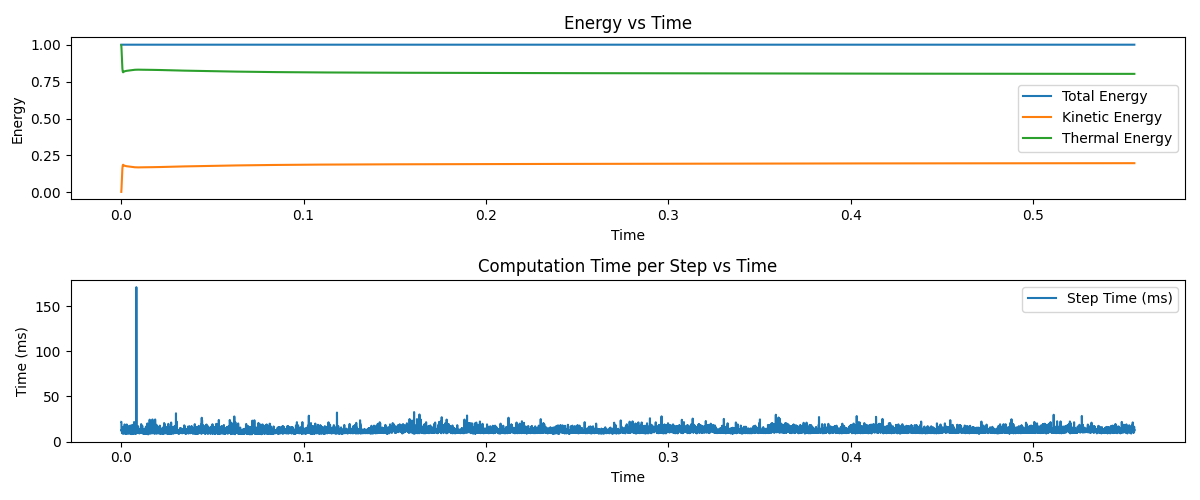

In [15]:
fig, axis = plt.subplots(2,1, figsize = (12, 5), squeeze = False)

axis[0,0].plot(times, [x[2] for x in trajectory], label = 'Total Energy')
axis[0,0].plot(times, [x[3] for x in trajectory], label = 'Kinetic Energy')
axis[0,0].plot(times, [x[4] for x in trajectory], label = 'Thermal Energy')
axis[0,0].legend()
axis[0,0].set_xlabel('Time')
axis[0,0].set_ylabel('Energy')
axis[0,0].set_title('Energy vs Time')

axis[1,0].plot(times, [x[5] for x in trajectory], label = 'Step Time (ms)')
axis[1,0].legend()
axis[1,0].set_xlabel('Time')
axis[1,0].set_ylabel('Time (ms)')
axis[1,0].set_title('Computation Time per Step vs Time')

fig.tight_layout()

In [16]:
print(f'Mean computation time per step: {sum(x[5] for x in trajectory)/len(trajectory):.3f} ms')
print(f'Max computation time for a step: {max(x[5] for x in trajectory):.3f} ms')
print(f'Stddev of computation time for steps: {torch.tensor([x[5] for x in trajectory]).std():.3f} ms')

Mean computation time per step: 12.105 ms
Max computation time for a step: 170.937 ms
Stddev of computation time for steps: 3.188 ms


Adjusted time for plotting: 0.5555510520935059
tensor(5.8897e-05, device='cuda:0')


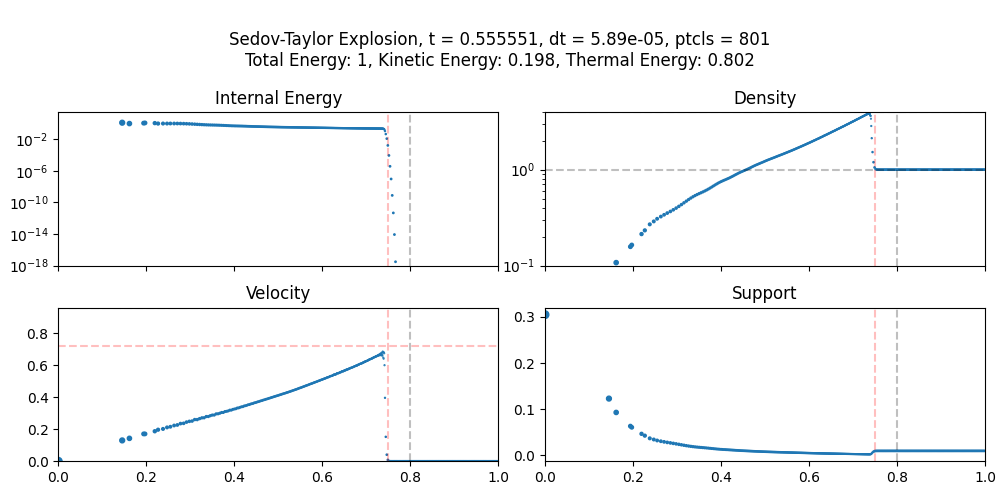

In [18]:
fig, axis = plt.subplots(2, 2, figsize=(10, 5), squeeze=False, sharex=True, sharey=False)

axis[0,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.internalEnergies.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[1,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.velocities.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[1,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.supports.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)

axis[0,0].set_title('Internal Energy')
axis[0,1].set_title('Density')
axis[1,0].set_title('Velocity')
axis[1,1].set_title('Support')

kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy

fig.suptitle(f'\nSedov-Taylor Explosion, t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
fig.tight_layout()

# prefix = './images/sedov_1d_201_sharp/'
# os.makedirs(prefix, exist_ok = True)

rt = rad_t(runningState.t)
# vt = vel_t(runningState.t)
    
    
def setupPlot(axis, t):
    vs, r2, v2, rho2, P2 = answer.shockState(t)
    rt = rad_t(t)
    
    for ax in axis.flatten():
        ax.axvline(r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(-r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(rt, color = 'red', linestyle = '--', alpha = 0.25)
        ax.axvline(-rt, color = 'red', linestyle = '--', alpha = 0.25)
        
        
    # axis[1,0].axhline(vt, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho0, color = 'black', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho2, color = 'black', linestyle = '--', alpha = 0.25)

    axis[0,0].set_xlim(0, 1)
    axis[0,1].set_xlim(0, 1)
    axis[1,0].set_xlim(0, 1)
    axis[1,1].set_xlim(0, 1)

    axis[0,0].set_ylim(1e-18, 30)
    axis[0,1].set_ylim(0.1, 4)
    axis[1,0].set_ylim(0, vs)

    axis[0,0].set_yscale('log')
    axis[0,1].set_yscale('log')

t = runningState.t.cpu() if isinstance(runningState.t, torch.Tensor) else runningState.t
# t = t * initial_dt.cpu().item() / config.dt
print(f"Adjusted time for plotting: {t}")
print(initial_dt)
setupPlot(axis, t)

# fig.savefig(f'{prefix}/frame_{0:06d}.png')

In [ ]:
currentState = runningState.state
verletScale = 1

adjacency = buildVerletList(
    currentState, 
    config.domain, verletScale = verletScale, supportMode = SupportScheme.SuperSymmetric,
    priorNeighborhood = None,
    verbose = False)

numNeighbors = adjacency.numNeighbors

currentState.densities = warpOperation(
    currentState,
    OperationProperties(
        kernel = config.kernel,
        operation = WarpOperation.Density,
        supportMode = config.supportMode,
    ),
    domain = config.domain,
    adjacency = adjacency,
)

currentState.entropies, _, currentState.pressures, currentState.soundspeeds = idealGasEOS(
    A = None,
    u = currentState.internalEnergies,
    P = None,
    rho = currentState.densities,
    gamma = compressibleSPHConfig.gamma,
)

from compressibleSPH.modules.adaptiveSupport import computeOmega
omega = computeOmega(currentState, 
        OperationProperties(
            kernel = config.kernel,
            supportMode = SupportScheme.Gather,
        ),
        domain = config.domain,
        adjacency = adjacency
)

gradHState = GradHState(
    queryOmegas = omega
)

# gradHState.queryOmegas = torch.ones_like(gradHState.queryOmegas)

In [ ]:
from diffSPH.schemes.states.compressiblesph import CompressibleState as CompState
from diffSPH.kernels import getSPHKernelv2
from diffSPH.neighborhood import evaluateNeighborhood

from diffSPH.modules.compSPH import compSPH_acceleration, compSPH_dudt, compute_fij

diffSPHDiffusionConfig = {    
    'diffusion':{
        'C_l': 1,
        'C_q': 2,
        'Cu_l': 1,
        'Cu_q': 2,
        'monaghanSwitch': True,
        'viscosityTerm': 'Monaghan',
        'correctXi': True,
        
        'viscosityFormulation': 'Monaghan1992',
        'thermalConductivityFormulation': 'Price2012_98',
        'signalTerm': 'Price2019',
        'K': 1.0,
        
        'thermalConductivity' : 0.5,
    },
    'diffusionSwitch':{
        'scheme': ViscositySwitch.NoneSwitch,
        'limitXi': False,
    },
    'domain': config.domain,
    'kernel': KernelType.Wendland2,
    'verbose': True,
}

diffSPHState = CompState(
    positions = currentState.positions,
    velocities = currentState.velocities,
    densities = currentState.densities,
    supports = currentState.supports,
    internalEnergies = currentState.internalEnergies,
    totalEnergies = currentState.totalEnergies,
    entropies = currentState.entropies,
    soundspeeds= currentState.soundspeeds,
    masses = currentState.masses,
    kinds = currentState.kinds,
    materials = currentState.materials,
    UIDs = currentState.UIDs,
    pressures = currentState.pressures,
    omega = gradHState.queryOmegas,
)

wrappedKernel = getSPHKernelv2(KernelType.Wendland2)
verletScale = 1
neighborhood, neighbors = evaluateNeighborhood(diffSPHState, config.domain, KernelType.Wendland2, verletScale = verletScale, mode = SupportScheme.SuperSymmetric, priorNeighborhood=None)


dvdt_dsph, ap_ij_dsph, av_ij_dsph = compSPH_acceleration(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, diffSPHDiffusionConfig)

print(f'Max pressure acceleration: {ap_ij_dsph.abs().max()}')
print(f'Max viscosity acceleration: {av_ij_dsph.abs().max()}')
print(f'Max total acceleration: {(dvdt_dsph).abs().max()}')

dudt_dsph = compSPH_dudt(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, diffSPHDiffusionConfig)

print(f'Max du/dt: {dudt_dsph.abs().max()}')

Max pressure acceleration: 644.6320190429688
Max viscosity acceleration: 513.4705200195312
Max total acceleration: 1097.9718017578125
Max du/dt: 1713.9971923828125


In [ ]:
compressibleSPHConfig.diffusionParams.viscosityTerm = 3
compressibleSPHConfig.diffusionParams.C_l = 1
compressibleSPHConfig.diffusionParams.C_q = 2
compressibleSPHConfig.diffusionParams.correctXi = True

In [ ]:
from sphWarpCore.kernels.wp_kernel import eval_packing
sphKernel_xi(config.kernel.value, config.dim), eval_kernelScale(config.dim, config.kernel.value), eval_packing(config.kernel.value)

(2.409215095, 2.20794, 1.487)

In [ ]:
print(config.kernel, config.kernel.value)

KernelFunctions.Wendland2 0


In [ ]:
from diffSPH.kernels import Kernel_xi, Kernel_Scale, eval_packingRatio
Kernel_xi(KernelType.Wendland2, config.dim), Kernel_Scale(KernelType.Wendland2, config.dim), eval_packingRatio(KernelType.Wendland2)

(2.409215095, 1.620185, 1.487)

In [ ]:
from compressibleSPH.modules.compSPH.accel import computeCompSPHAccelWarp

dvdt, pressureAccel_ij, viscosityAccel_ij = computeCompSPHAccelWarp(
    queryParticles = currentState,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = config.supportMode
    ),
    domain = config.domain,
    conductivityParams= compressibleSPHConfig.diffusionParams,

    queryEnergies = currentState.internalEnergies,
    queryVelocities= currentState.velocities,
    queryCs = currentState.soundspeeds,
    queryAlphas = currentState.alphas,
    queryPressures = currentState.pressures,

    adjacency = adjacency,
    gradHState = gradHState
)
print(f'Max pressure acceleration: {pressureAccel_ij.abs().max()}')
print(f'Max viscosity acceleration: {viscosityAccel_ij.abs().max()}')
print(f'Max total acceleration: {(dvdt).abs().max()}')

Max pressure acceleration: 644.6320190429688
Max viscosity acceleration: 513.470458984375
Max total acceleration: 1097.9716796875


In [ ]:
print(f'Max difference in pressure acceleration: {(pressureAccel_ij - ap_ij_dsph).abs().max()}')
print(f'Max difference in viscosity acceleration: {(viscosityAccel_ij - av_ij_dsph).abs().max()}')
print(f'Max difference in total acceleration: {(dvdt - dvdt_dsph).abs().max()}')

Max difference in pressure acceleration: 0.0001220703125
Max difference in viscosity acceleration: 0.000152587890625
Max difference in total acceleration: 0.000244140625


In [ ]:
viscosityAccel_ij[viscosityAccel_ij.abs() > 1e-3]

tensor([-2.8952e-03, -1.3735e-02, -7.3059e-02, -1.0228e-03, -3.7896e-02,
        -4.2901e-01, -6.0238e-01, -1.1206e-01,  2.8952e-03,  1.3735e-02,
         3.7895e-02, -1.3105e+00, -5.7441e+00, -4.6099e+00, -2.2718e+00,
        -2.6743e-01,  7.3054e-02,  4.2902e-01,  1.3104e+00, -1.9595e+01,
        -3.6851e+01, -1.9811e+01, -1.1277e+01, -5.1101e+00, -1.2410e+00,
         1.0238e-03,  6.0238e-01,  5.7443e+00,  1.9595e+01, -1.7045e+02,
        -1.2107e+02, -4.9943e+01, -2.8602e+01, -1.2304e+01, -2.1676e+00,
         1.1208e-01,  4.6097e+00,  3.6851e+01,  1.7046e+02, -5.1346e+02,
        -3.0872e+02, -8.1415e+01, -3.2260e+01, -6.4700e+00, -1.9034e-03,
         2.2716e+00,  1.9811e+01,  1.2108e+02,  5.1346e+02, -3.5707e+02,
        -2.1219e+02, -5.2532e+01, -3.0644e+00,  2.6751e-01,  1.1276e+01,
         4.9943e+01,  3.0870e+02,  3.5704e+02, -7.6278e+01,  5.1097e+00,
         2.8602e+01,  8.1407e+01,  2.1217e+02,  7.6278e+01,  1.2410e+00,
         1.2305e+01,  3.2260e+01,  5.2532e+01, -7.5

In [ ]:
# Max du/dt: 3417.611328125, Max du/dt diffSPH: 1713.9971923828125
# Max Diff: 1703.6141357421875
# Max du/dt: 3395.027099609375, Max du/dt diffSPH: 1703.37109375
# Max Diff: 1691.656005859375
# Max du/dt: 3395.327880859375, Max du/dt diffSPH: 1703.5166015625
# Max Diff: 1691.811279296875
# Max du/dt: 3373.2021484375, Max du/dt diffSPH: 1693.142578125
# Max Diff: 1680.0595703125

In [ ]:
config.supportMode

<SupportScheme.Gather: 11>

In [ ]:
from compressibleSPH.modules.compSPH.dudt import computeCompSPHdudtWarp
from sphWarpCore.enumTypes import SupportScheme
dudt = computeCompSPHdudtWarp(
    queryParticles = currentState,
    operationProperties = OperationProperties(
        kernel = config.kernel,
        supportMode = SupportScheme.Gather
    ),
    domain = config.domain,
    conductivityParams= compressibleSPHConfig.diffusionParams,

    queryEnergies = currentState.internalEnergies,
    queryVelocities= currentState.velocities,
    queryCs = currentState.soundspeeds,
    queryAlphas = currentState.alphas,
    queryPressures = currentState.pressures,

    adjacency = adjacency,
    gradHState = gradHState
)
print(f'Max du/dt: {dudt.abs().max()}')

Max du/dt: 3417.611328125


In [ ]:
from diffSPH.enums import SupportScheme as DiffSPHSupportScheme
dudt_dsph = compSPH_dudt(diffSPHState, wrappedKernel, neighbors.get('noghost'), DiffSPHSupportScheme.Gather, diffSPHDiffusionConfig)

print(f'Max du/dt: {dudt_dsph.abs().max()}')

Max du/dt: 1713.99755859375


In [26]:
dudt[dudt.abs() > 1e-3], dudt_dsph[dudt_dsph.abs() > 1e-3], (dudt / dudt_dsph)[(dudt.abs() > 1e-3) | (dudt_dsph.abs() > 1e-3)]

(tensor([ 2.3929e-03,  1.4522e-01,  5.2197e+00,  5.7400e+01,  2.8110e+02,
          8.0004e+02,  8.3915e+02,  5.9904e+02,  2.5041e+02, -4.0072e+00,
         -9.4935e+01,  8.4828e+01,  7.2798e+01, -8.1961e+01, -2.5443e+02,
         -3.1816e+02, -2.3370e+02, -1.5674e+02, -1.1915e+02, -1.3109e+02,
         -1.5386e+02, -1.7737e+02, -1.4204e+02, -8.4432e+01, -8.0714e+01,
         -4.4229e+03, -8.0712e+01, -8.4431e+01, -1.4204e+02, -1.7737e+02,
         -1.5386e+02, -1.3108e+02, -1.1915e+02, -1.5673e+02, -2.3370e+02,
         -3.1816e+02, -2.5445e+02, -8.1961e+01,  7.2802e+01,  8.4828e+01,
         -9.4939e+01, -4.0099e+00,  2.5044e+02,  5.9907e+02,  8.3914e+02,
          8.0002e+02,  2.8110e+02,  5.7399e+01,  5.2195e+00,  1.4524e-01,
          2.3929e-03], device='cuda:0'),
 tensor([ 2.3929e-03,  1.4522e-01,  5.2197e+00,  5.7400e+01,  2.8110e+02,
          8.0004e+02,  8.3915e+02,  5.9904e+02,  2.5041e+02, -4.0072e+00,
         -9.4935e+01,  8.4828e+01,  7.2798e+01, -8.1961e+01, -2.5443e+0

In [ ]:
from diffSPH.enums import EnergyScheme as EnergySchemeDiffSPH
v_halfstep = diffSPHState.velocities + 0.5 * config.dt * dvdt


energyScheme = EnergyScheme.CRK
print(f'Energy scheme: {energyScheme} [value: {energyScheme.value}]' )


# f_ij
print(f_ij)
print(f'Max f_ij: {f_ij.abs().max()}, Mean: {f_ij.mean()}, Min: {f_ij.min()}, Max: {f_ij.max()}')
print(f'Max deviation from 0.5: {(f_ij - 0.5).abs().max()}')

diffSPHDiffusionConfig['energyScheme'] = EnergySchemeDiffSPH.CRK
f_ij_dsph = compute_fij(diffSPHState, wrappedKernel, neighbors.get('noghost'), SupportScheme.SuperSymmetric, diffSPHDiffusionConfig, config.dt, v_halfstep, ap_ij_dsph, av_ij_dsph)
# print(f_ij_dsph)
print(f'Max f_ij (diffSPH): {f_ij_dsph.abs().max()}, Mean: {f_ij_dsph.mean()}, Min: {f_ij_dsph.min()}, Max: {f_ij_dsph.max()}')
print(f'Max deviation from 0.5 (diffSPH): {(f_ij_dsph - 0.5).abs().max()}')

print(f'Max difference in f_ij: {(f_ij - f_ij_dsph).abs().max()}')

Energy scheme: EnergyScheme.CRK [value: 5]
tensor([0.4942, 0.4961, 0.5020,  ..., 0.4980, 0.4961, 0.4941], device='cuda:0')
Max f_ij: 0.9941655993461609, Mean: 0.5, Min: 0.0058343675918877125, Max: 0.9941655993461609
Max deviation from 0.5: 0.4941656291484833
Max f_ij (diffSPH): 0.9941656589508057, Mean: 0.5, Min: 0.005834357813000679, Max: 0.9941656589508057
Max deviation from 0.5 (diffSPH): 0.49416565895080566
Max difference in f_ij: 1.0132789611816406e-06


In [19]:
print('Max pressure deviation:', (ap_ij_dsph - pressureAccel_ij).abs().max())
print('Max viscosity deviation:', (av_ij_dsph - viscosityAccel_ij).abs().max())
print('Max total acceleration deviation:', (dvdt_dsph - dvdt).abs().max())
print('Max du/dt deviation:', (dudt_dsph - dudt).abs().max())

Max pressure deviation: tensor(0.0005, device='cuda:0')
Max viscosity deviation: tensor(9.5367e-07, device='cuda:0')
Max total acceleration deviation: tensor(0.0011, device='cuda:0')
Max du/dt deviation: tensor(0.0078, device='cuda:0')


In [33]:
pressureAccel_ij
# viscosityAccel_ij

tensor([[  354.6518],
        [  945.7905],
        [ 1061.2377],
        ...,
        [-1061.2208],
        [ -938.4009],
        [ -349.1239]], device='cuda:0')

In [40]:
config.dt = 1e-4
t_limit = goalTime
nSteps = int(t_limit / config.dt)

print(f"Running with dt: {config.dt}, which gives nSteps: {nSteps}")
nSteps = 512

runningState = compSystem.initializeNewState()
for i in (tq := tqdm(range(nSteps), leave = True)):
    result = integrator.function(
        state = runningState,
        f = compressibleSPH_Monaghan,
        dt = config.dt,  
        config = config,
        compParams = compressibleSPHConfig,
        verbose = False,
    )

    runningState = result.state

Running with dt: 0.0001, which gives nSteps: 5556


  0%|          | 0/512 [00:00<?, ?it/s]

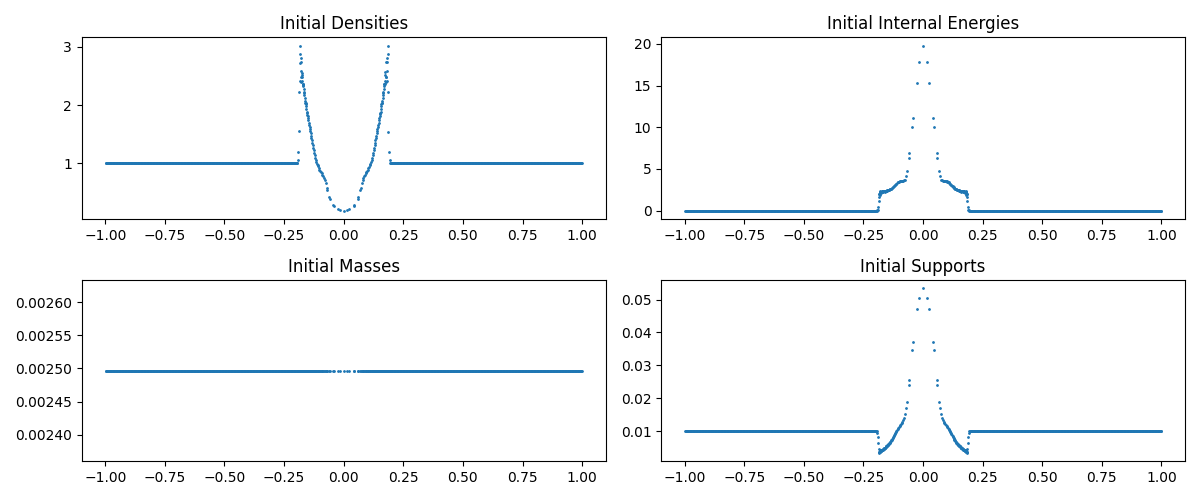

In [41]:
fig, axis = plt.subplots(2,2, figsize = (12, 5), squeeze = False)
plotToAxis1D(axis[0,0], runningState.state.positions, runningState.state.densities, title = 'Initial Densities')
plotToAxis1D(axis[1,0], runningState.state.positions, runningState.state.masses, title = 'Initial Masses')
plotToAxis1D(axis[0,1], runningState.state.positions, runningState.state.internalEnergies, title = 'Initial Internal Energies')
plotToAxis1D(axis[1,1], runningState.state.positions, runningState.state.supports, title = 'Initial Supports')
fig.tight_layout()

Adjusted time for plotting: 0.05120000000000044
tensor(0.0914, device='cuda:0')


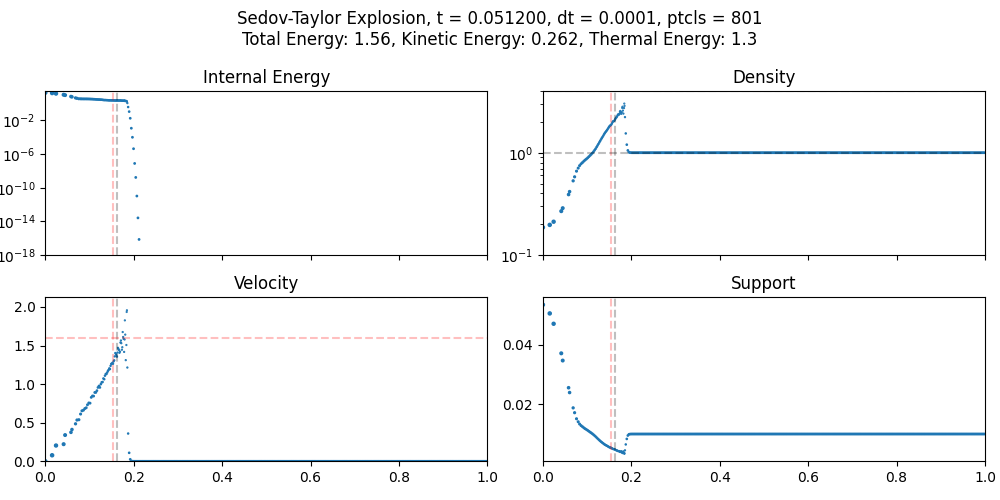

In [42]:
fig, axis = plt.subplots(2, 2, figsize=(10, 5), squeeze=False, sharex=True, sharey=False)

axis[0,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.internalEnergies.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[0,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.densities.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[1,0].scatter(runningState.state.positions.cpu().numpy(), runningState.state.velocities.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)
axis[1,1].scatter(runningState.state.positions.cpu().numpy(), runningState.state.supports.cpu().numpy(), s = runningState.state.supports.cpu().numpy() * 100)

axis[0,0].set_title('Internal Energy')
axis[0,1].set_title('Density')
axis[1,0].set_title('Velocity')
axis[1,1].set_title('Support')

kineticEnergy = 0.5 * (torch.linalg.norm(runningState.state.velocities, dim = -1) **2 * runningState.state.masses).sum()
thermalEnergy = (runningState.state.internalEnergies * runningState.state.masses).sum()
totalEnergy = kineticEnergy + thermalEnergy

fig.suptitle(f'Sedov-Taylor Explosion, t = {runningState.t:2f}, dt = {config.dt:.3g}, ptcls = {len(runningState.state.positions)}\nTotal Energy: {totalEnergy:.3g}, Kinetic Energy: {kineticEnergy:.3g}, Thermal Energy: {thermalEnergy:.3g}')
fig.tight_layout()

# prefix = './images/sedov_1d_201_sharp/'
# os.makedirs(prefix, exist_ok = True)

rt = rad_t(runningState.t)
# vt = vel_t(runningState.t)
    
    
def setupPlot(axis, t):
    vs, r2, v2, rho2, P2 = answer.shockState(t)
    rt = rad_t(t)
    
    for ax in axis.flatten():
        ax.axvline(r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(-r2, color = 'black', linestyle = '--', alpha = 0.25)
        ax.axvline(rt, color = 'red', linestyle = '--', alpha = 0.25)
        ax.axvline(-rt, color = 'red', linestyle = '--', alpha = 0.25)
        
        
    # axis[1,0].axhline(vt, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-vs, color = 'black', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[1,0].axhline(-v2, color = 'red', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho0, color = 'black', linestyle = '--', alpha = 0.25)
    axis[0,1].axhline(rho2, color = 'black', linestyle = '--', alpha = 0.25)

    axis[0,0].set_xlim(0, 1)
    axis[0,1].set_xlim(0, 1)
    axis[1,0].set_xlim(0, 1)
    axis[1,1].set_xlim(0, 1)

    axis[0,0].set_ylim(1e-18, 30)
    axis[0,1].set_ylim(0.1, 4)
    axis[1,0].set_ylim(0, vs)

    axis[0,0].set_yscale('log')
    axis[0,1].set_yscale('log')

t = runningState.t.cpu() if isinstance(runningState.t, torch.Tensor) else runningState.t
# t = t * initial_dt.cpu().item() / config.dt
print(f"Adjusted time for plotting: {t}")
print(initial_dt)
setupPlot(axis, t)

# fig.savefig(f'{prefix}/frame_{0:06d}.png')